# **HR ANALYTICS BY IBM DATASET**

## Employee Attrition Analysis using Python

**Author:** Tiara Azahra Wika Putri

This project performs an end-to-end Human Resources Analytics workflow using the IBM HR Analytics Employee Attrition dataset. The analysis aims to identify employee characteristics associated with attrition and generate actionable business insights for HR decision-makers.

#**1. Project Introduction**

Employee attrition is one of the major challenges faced by organizations. High employee turnover increases recruitment costs, reduces productivity, and negatively impacts organizational performance.

This project analyzes employee demographics, job characteristics, income, tenure, and satisfaction to understand factors related to employee attrition.

# **2. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **3. Load Dataset**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving data_IBM.csv to data_IBM.csv


In [3]:
df = pd.read_csv("data_IBM.csv")

# **4. Data Understanding**

In [4]:
df.shape

(1470, 35)

In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


In [10]:
(df["Attrition"].value_counts(normalize=True) * 100).round(2)

,proportion
Attrition,
No,83.88
Yes,16.12


In [11]:
for col in df.columns:
    print(col, ":", df[col].nunique())

Age : 43
Attrition : 2
BusinessTravel : 3
DailyRate : 886
Department : 3
DistanceFromHome : 29
Education : 5
EducationField : 6
EmployeeCount : 1
EmployeeNumber : 1470
EnvironmentSatisfaction : 4
Gender : 2
HourlyRate : 71
JobInvolvement : 4
JobLevel : 5
JobRole : 9
JobSatisfaction : 4
MaritalStatus : 3
MonthlyIncome : 1349
MonthlyRate : 1427
NumCompaniesWorked : 10
Over18 : 1
OverTime : 2
PercentSalaryHike : 15
PerformanceRating : 2
RelationshipSatisfaction : 4
StandardHours : 1
StockOptionLevel : 4
TotalWorkingYears : 40
TrainingTimesLastYear : 7
WorkLifeBalance : 4
YearsAtCompany : 37
YearsInCurrentRole : 19
YearsSinceLastPromotion : 16
YearsWithCurrManager : 18


# **5. Data Cleaning**

The dataset contains no missing values and no duplicate records. Therefore, no data cleaning procedures such as imputation or duplicate removal were required.

In [12]:
df = df.drop(columns=[
    "EmployeeCount",
    "Over18",
    "StandardHours",
    "EmployeeNumber"
])

df.shape

(1470, 31)

In [14]:
df["IncomeLevel"] = pd.qcut(
    df["MonthlyIncome"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [15]:
df["IncomeLevel"].value_counts()

,count
IncomeLevel,
Low,490
Medium,490
High,490


In [16]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[18, 30, 40, 50, 60],
    labels=["18-30", "31-40", "41-50", "51-60"]
)

In [17]:
df["AgeGroup"].value_counts()

,count
AgeGroup,
31-40,619
18-30,378
41-50,322
51-60,143


In [18]:
df["TenureGroup"] = pd.cut(
    df["YearsAtCompany"],
    bins=[-1, 5, 10, 20, 40],
    labels=[
        "0-5 Years",
        "6-10 Years",
        "11-20 Years",
        "20+ Years"
    ]
)

In [19]:
df["TenureGroup"].value_counts()

,count
TenureGroup,
0-5 Years,776
6-10 Years,448
11-20 Years,180
20+ Years,66


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Age                       1470 non-null   int64   
 1   Attrition                 1470 non-null   object  
 2   BusinessTravel            1470 non-null   object  
 3   DailyRate                 1470 non-null   int64   
 4   Department                1470 non-null   object  
 5   DistanceFromHome          1470 non-null   int64   
 6   Education                 1470 non-null   int64   
 7   EducationField            1470 non-null   object  
 8   EnvironmentSatisfaction   1470 non-null   int64   
 9   Gender                    1470 non-null   object  
 10  HourlyRate                1470 non-null   int64   
 11  JobInvolvement            1470 non-null   int64   
 12  JobLevel                  1470 non-null   int64   
 13  JobRole                   1470 non-null   object

In [21]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[18,30,40,50,60],
    labels=["18-30","31-40","41-50","51-60"],
    include_lowest=True
)

In [22]:
df["AgeGroup"].isna().sum()

np.int64(0)

# **6. Feature Engineering**

Feature engineering was performed to improve data interpretability and simplify business analysis.

The following new variables were created:

- **IncomeLevel**
  - Categorized Monthly Income into:
    - Low
    - Medium
    - High
  - Created using quantile-based binning (`pd.qcut`).

- **AgeGroup**
  - Grouped employees into:
    - 18–30
    - 31–40
    - 41–50
    - 51–60

- **TenureGroup**
  - Grouped Years at Company into:
    - 0–5 Years
    - 6–10 Years
    - 11–20 Years
    - 20+ Years

These engineered features help identify employee attrition patterns more clearly than raw numerical variables. **teks tebal**

## - Income Level

Monthly income is categorized into three groups:

- Low
- Medium
- High

using quantile-based segmentation.

In [117]:
# Create Income Level

df["IncomeLevel"] = pd.qcut(
    df["MonthlyIncome"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df["IncomeLevel"].value_counts()

,count
IncomeLevel,
Low,490
Medium,490
High,490


The workforce is distributed into three balanced income categories, making it easier to compare attrition rates across salary groups.

##-  Age Group

Employees are categorized according to their age to better understand demographic trends related to attrition.

In [118]:
# Create Age Group

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[18, 30, 40, 50, 60],
    labels=["18-30", "31-40", "41-50", "51-60"],
    include_lowest=True
)

df["AgeGroup"].value_counts().sort_index()

,count
AgeGroup,
18-30,386
31-40,619
41-50,322
51-60,143


Most employees fall within the 31–40 age range, which represents the largest workforce segment.

##- Tenure Group

Employees are grouped based on their years at the company to analyze employee retention over time.

In [119]:
# Create Tenure Group

df["TenureGroup"] = pd.cut(
    df["YearsAtCompany"],
    bins=[-1, 5, 10, 20, 40],
    labels=[
        "0-5 Years",
        "6-10 Years",
        "11-20 Years",
        ">20 Years"
    ]
)

df["TenureGroup"].value_counts().sort_index()

,count
TenureGroup,
0-5 Years,776
6-10 Years,448
11-20 Years,180
>20 Years,66


Grouping tenure simplifies the identification of turnover patterns among new and long-term employees.

##-  Feature Engineering Result

The newly created variables are displayed below.

In [120]:
df[[
    "MonthlyIncome",
    "IncomeLevel",
    "Age",
    "AgeGroup",
    "YearsAtCompany",
    "TenureGroup"
]].head(10)

,MonthlyIncome,IncomeLevel,Age,AgeGroup,YearsAtCompany,TenureGroup
0,5993,Medium,41,41-50,6,6-10 Years
1,5130,Medium,49,41-50,10,6-10 Years
2,2090,Low,37,31-40,0,0-5 Years
3,2909,Low,33,31-40,8,6-10 Years
4,3468,Low,27,18-30,2,0-5 Years
5,3068,Low,32,31-40,7,6-10 Years
6,2670,Low,59,51-60,1,0-5 Years
7,2693,Low,30,18-30,1,0-5 Years
8,9526,High,38,31-40,9,6-10 Years
9,5237,Medium,36,31-40,7,6-10 Years


In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Age                       1470 non-null   int64   
 1   Attrition                 1470 non-null   object  
 2   BusinessTravel            1470 non-null   object  
 3   DailyRate                 1470 non-null   int64   
 4   Department                1470 non-null   object  
 5   DistanceFromHome          1470 non-null   int64   
 6   Education                 1470 non-null   int64   
 7   EducationField            1470 non-null   object  
 8   EnvironmentSatisfaction   1470 non-null   int64   
 9   Gender                    1470 non-null   object  
 10  HourlyRate                1470 non-null   int64   
 11  JobInvolvement            1470 non-null   int64   
 12  JobLevel                  1470 non-null   int64   
 13  JobRole                   1470 non-null   object

-------------------------------------

# **7. Exploratory Data Analysis (EDA)**

The objective of Exploratory Data Analysis (EDA) is to identify employee attrition patterns and understand the relationship between employee characteristics and turnover.

The analysis focuses on answering key business questions such as:

- What is the overall attrition rate?
- Which departments have the highest employee attrition?
- Does overtime influence employee attrition?
- Which age groups are more likely to leave?
- How does income relate to employee attrition?
- Which job roles experience the highest turnover?

------------------------------

In [45]:
def add_value_labels(ax):
    """
    Menambahkan label angka di atas setiap bar.
    """
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.0f",
            padding=3,
            fontsize=10
        )

In [64]:
def add_percentage_labels(ax):
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3,
            fontsize=10
        )

## Employee Attrition Distribution

This visualization shows the proportion of employees who stayed and those who left the company.

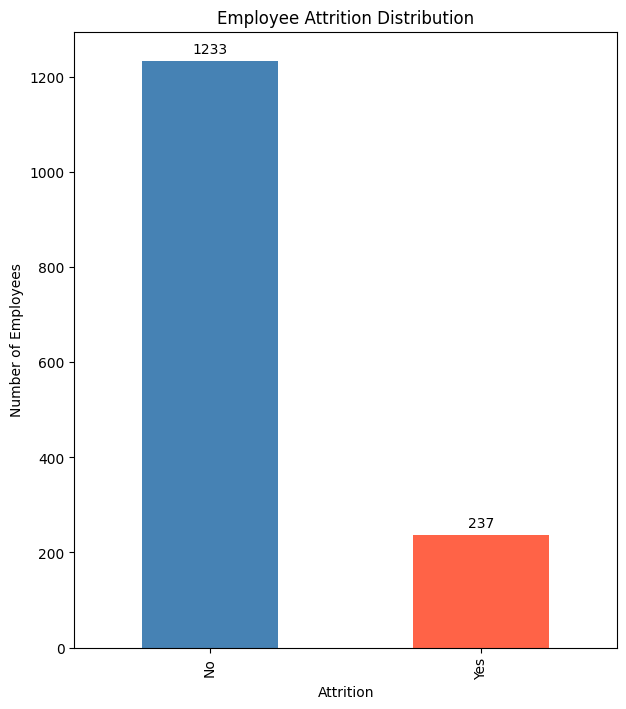

In [49]:
attrition = df["Attrition"].value_counts()

fig, ax = plt.subplots(figsize=(7,8))

attrition.plot(
    kind="bar",
    ax=ax,
    color=["steelblue","tomato"]
)

ax.set_title("Employee Attrition Distribution")
ax.set_xlabel("Attrition")
ax.set_ylabel("Number of Employees")

add_value_labels(ax)

plt.show()

## Attrition Rate

This chart illustrates the percentage of employees who left versus those who remained.

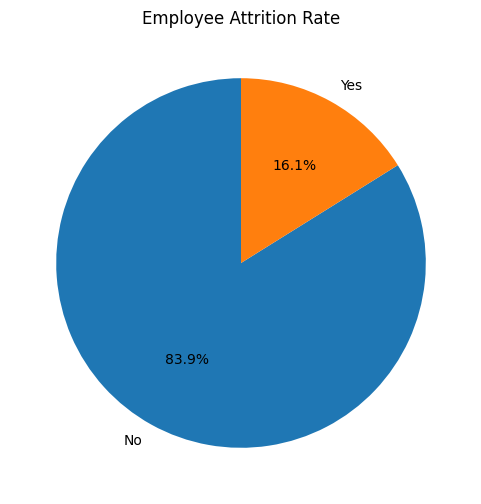

In [31]:
plt.figure(figsize=(6,6))

df["Attrition"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Employee Attrition Rate")

plt.show()

## Attrition by Department

This analysis compares employee attrition across different departments.

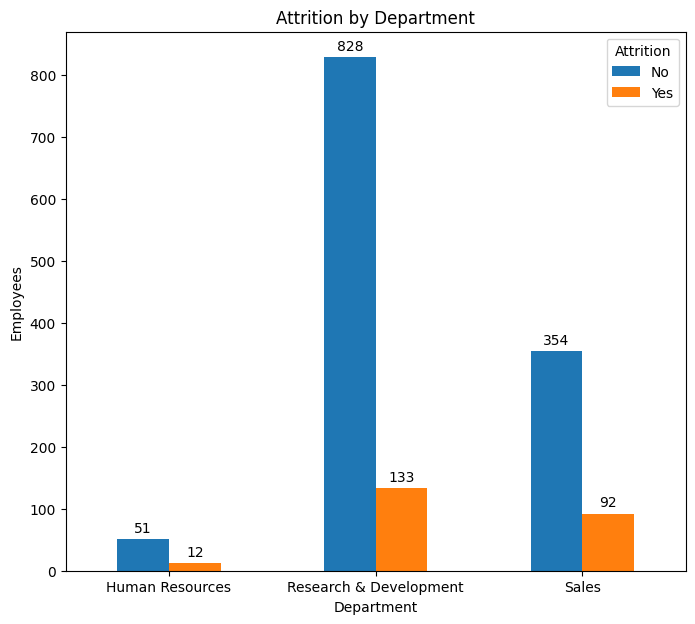

In [51]:
dept = pd.crosstab(
    df["Department"],
    df["Attrition"]
)

fig, ax = plt.subplots(figsize=(8,7))

dept.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Attrition by Department")
ax.set_xlabel("Department")
ax.set_ylabel("Employees")

add_value_labels(ax)

plt.xticks(rotation=0)

plt.show()

## Attrition by Gender

This visualization compares employee turnover between male and female employees.

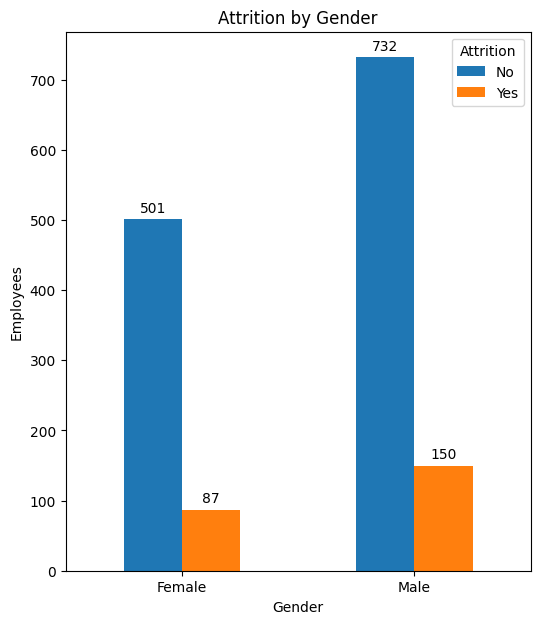

In [53]:
gender = pd.crosstab(
    df["Gender"],
    df["Attrition"]
)

fig, ax = plt.subplots(figsize=(6,7))

gender.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Attrition by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Employees")

add_value_labels(ax)

plt.xticks(rotation=0)

plt.show()

## Attrition by Overtime

This analysis investigates whether employees working overtime are more likely to leave the company.

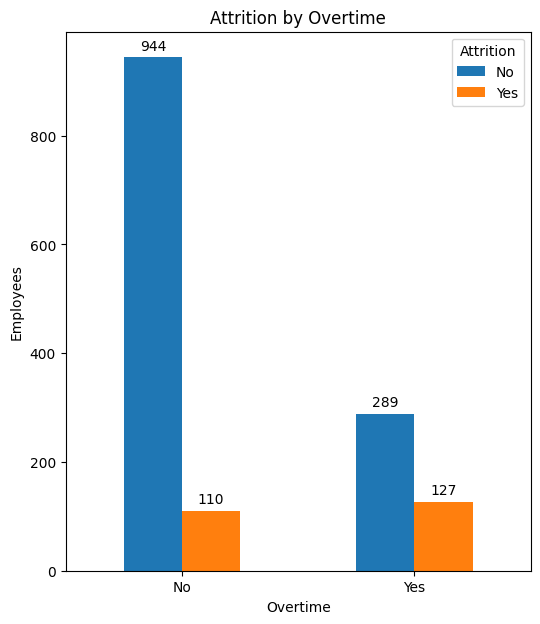

In [55]:
overtime = pd.crosstab(
    df["OverTime"],
    df["Attrition"]
)

fig, ax = plt.subplots(figsize=(6,7))

overtime.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Attrition by Overtime")
ax.set_xlabel("Overtime")
ax.set_ylabel("Employees")

add_value_labels(ax)

plt.xticks(rotation=0)

plt.show()

--------------------------------

# **Advanced Exploratory Data Analysis**

This section explores the factors that may influence employee attrition, including job role, age, income level, years at the company, overtime, and salary.

The objective is to identify employee segments with the highest turnover risk and provide actionable business insights.

## Attrition by Job Role

This analysis identifies which job roles experience the highest employee turnover.

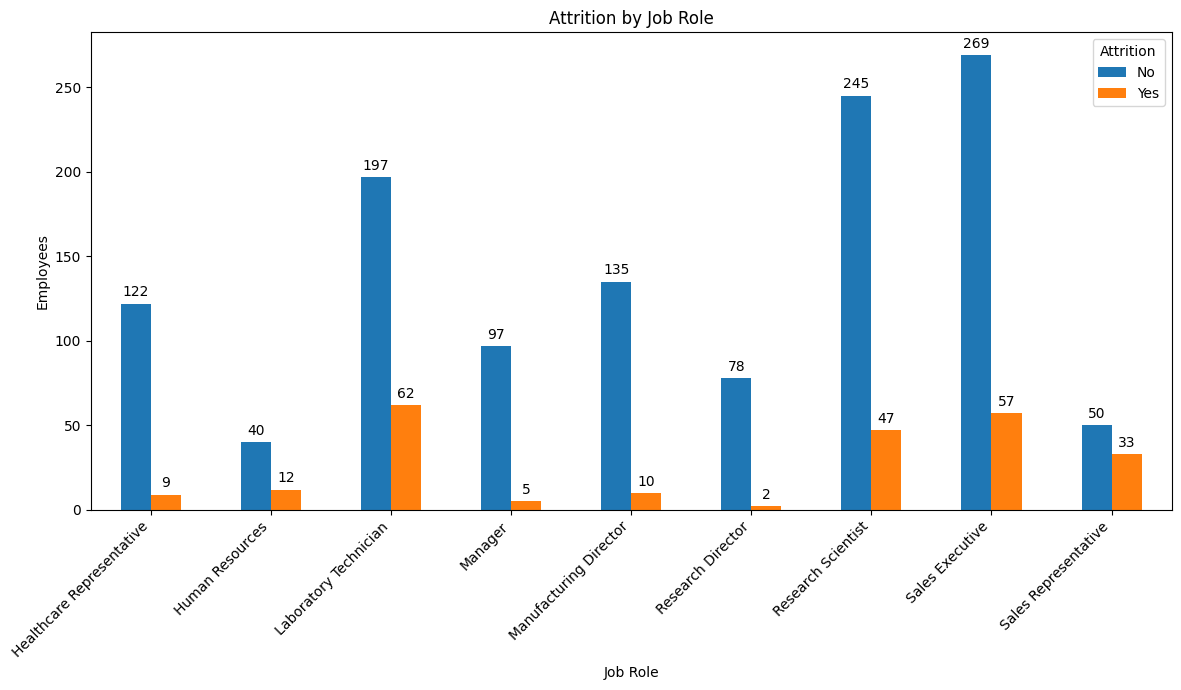

In [57]:
job_role = pd.crosstab(
    df["JobRole"],
    df["Attrition"]
)

fig, ax = plt.subplots(figsize=(12,7))

job_role.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Attrition by Job Role")
ax.set_xlabel("Job Role")
ax.set_ylabel("Employees")

add_value_labels(ax)

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

Attrition Rate by Job Role

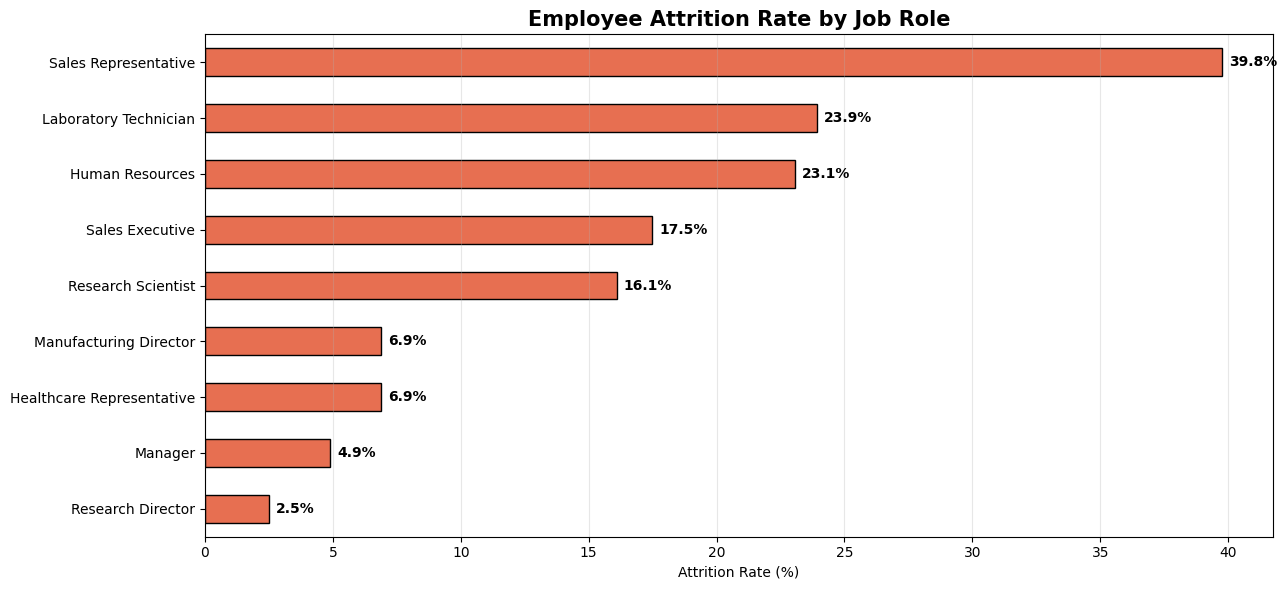

In [70]:
fig, ax = plt.subplots(figsize=(13,6))

bars = jobrole_rate["Yes"].sort_values().plot(
    kind="barh",
    color="#E76F51",
    edgecolor="black",
    ax=ax
)

ax.bar_label(
    ax.containers[0],
    fmt="%.1f%%",
    padding=5,
    fontsize=10,
    weight="bold"
)

ax.set_title(
    "Employee Attrition Rate by Job Role",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Attrition Rate (%)")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## Attrition by Age Group

This visualization shows employee turnover across different age groups.

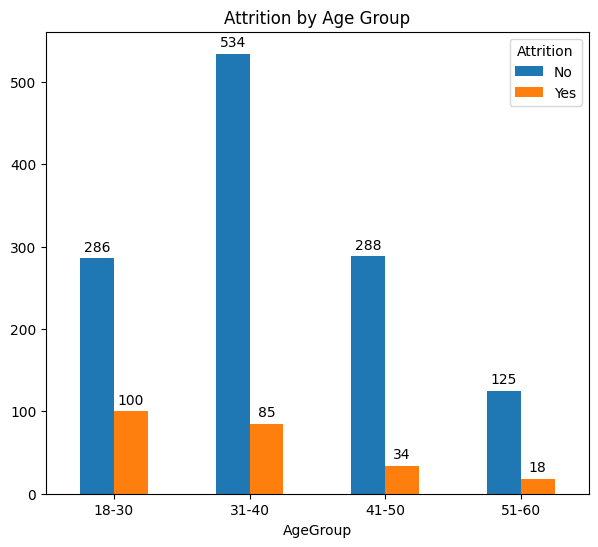

In [59]:
age_group = pd.crosstab(
    df["AgeGroup"],
    df["Attrition"]
)

fig, ax = plt.subplots(figsize=(7,6))

age_group.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Attrition by Age Group")

add_value_labels(ax)

plt.xticks(rotation=0)

plt.show()

Attrition Rate by Age Group

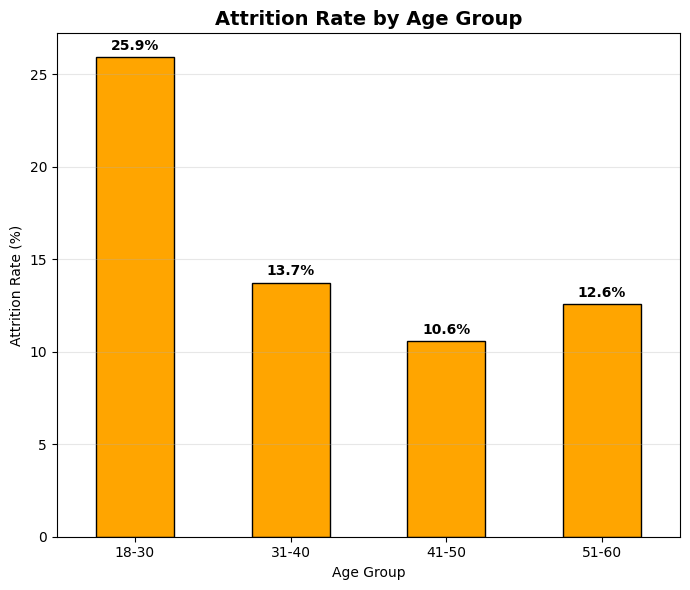

In [72]:
fig, ax = plt.subplots(figsize=(7,6))

age_rate = pd.crosstab(
    df["AgeGroup"],
    df["Attrition"],
    normalize="index"
) * 100

age_rate["Yes"].plot(
    kind="bar",
    color="orange",
    edgecolor="black",
    ax=ax
)

ax.set_title("Attrition Rate by Age Group", fontsize=14, weight="bold")
ax.set_xlabel("Age Group")
ax.set_ylabel("Attrition Rate (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Menambahkan label persentase
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=10,
        weight="bold"
    )

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Attrition by Income Level

This analysis investigates whether employees with lower salaries are more likely to leave

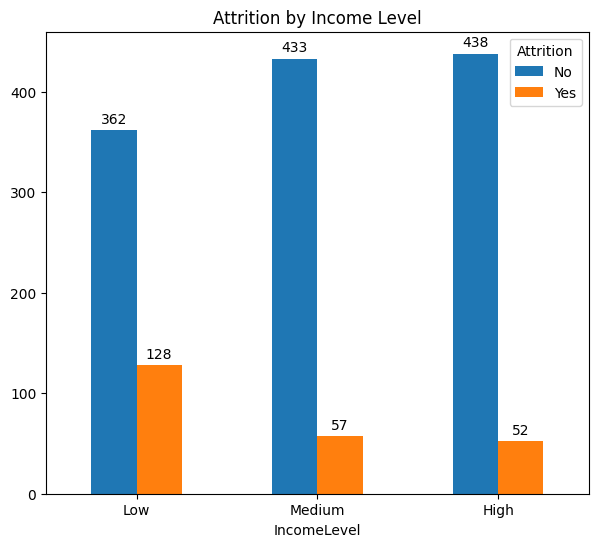

In [61]:
income = pd.crosstab(
    df["IncomeLevel"],
    df["Attrition"]
)

fig, ax = plt.subplots(figsize=(7,6))

income.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Attrition by Income Level")

add_value_labels(ax)

plt.xticks(rotation=0)

plt.show()

Attrition Rate by Income Level

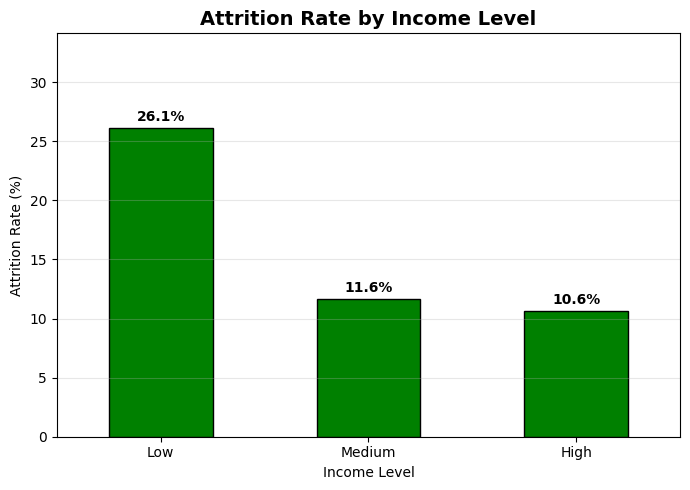

In [73]:
fig, ax = plt.subplots(figsize=(7,5))

income_rate = pd.crosstab(
    df["IncomeLevel"],
    df["Attrition"],
    normalize="index"
) * 100

income_rate["Yes"].plot(
    kind="bar",
    color="green",
    edgecolor="black",
    ax=ax
)

ax.set_title("Attrition Rate by Income Level", fontsize=14, weight="bold")
ax.set_xlabel("Income Level")
ax.set_ylabel("Attrition Rate (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Menampilkan nilai persentase di atas bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=10,
        weight="bold"
    )

# Tambahkan grid
ax.grid(axis="y", alpha=0.3)

# Beri sedikit ruang di atas agar label tidak terpotong
ax.set_ylim(0, income_rate["Yes"].max() + 8)

plt.tight_layout()
plt.show()

## Attrition by Years at Company

This analysis compares employee turnover across tenure groups.

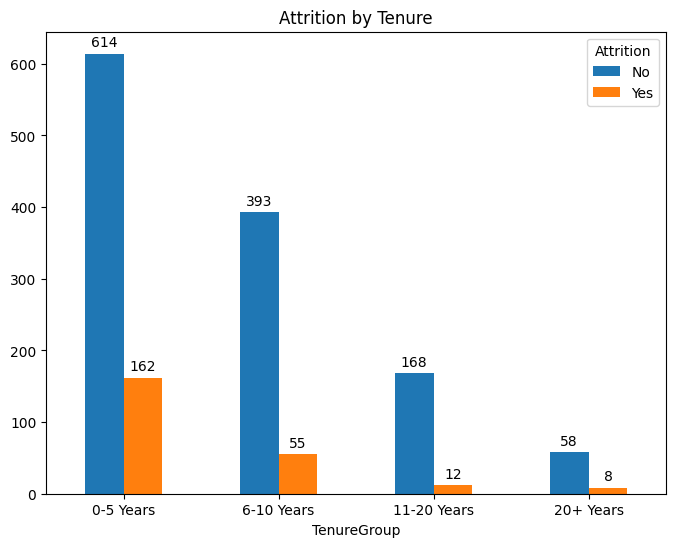

In [63]:
tenure = pd.crosstab(
    df["TenureGroup"],
    df["Attrition"]
)

fig, ax = plt.subplots(figsize=(8,6))

tenure.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Attrition by Tenure")

add_value_labels(ax)

plt.xticks(rotation=0)

plt.show()

Attrition Rate by Tenure

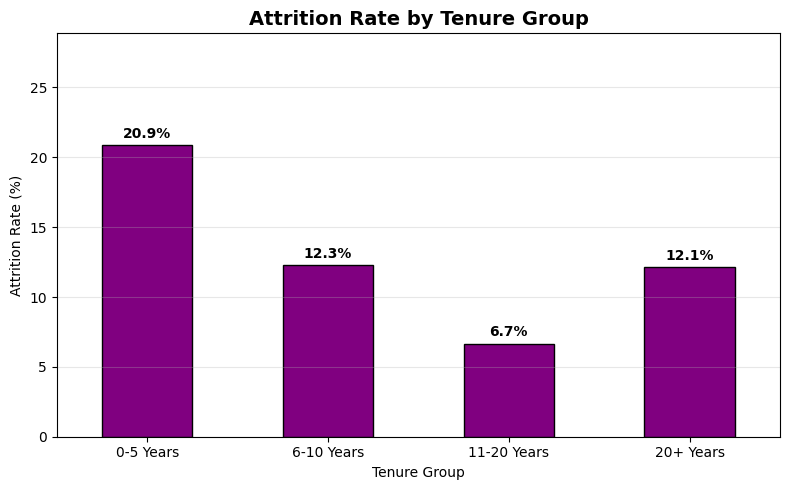

In [74]:
fig, ax = plt.subplots(figsize=(8,5))

tenure_rate = pd.crosstab(
    df["TenureGroup"],
    df["Attrition"],
    normalize="index"
) * 100

tenure_rate["Yes"].plot(
    kind="bar",
    color="purple",
    edgecolor="black",
    ax=ax
)

ax.set_title("Attrition Rate by Tenure Group", fontsize=14, weight="bold")
ax.set_xlabel("Tenure Group")
ax.set_ylabel("Attrition Rate (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Menambahkan label persentase
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=10,
        weight="bold"
    )

# Grid
ax.grid(axis="y", alpha=0.3)

# Memberi ruang di atas bar agar label tidak terpotong
ax.set_ylim(0, tenure_rate["Yes"].max() + 8)

plt.tight_layout()
plt.show()

Monthly Income Distribution

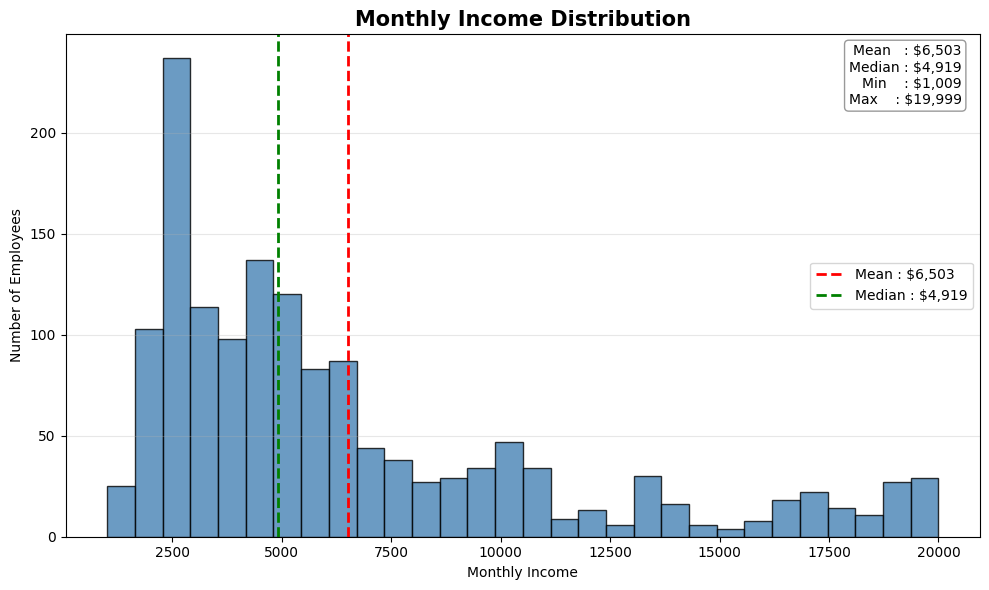

In [78]:
fig, ax = plt.subplots(figsize=(10,6))

ax.hist(
    df["MonthlyIncome"],
    bins=30,
    color="steelblue",
    edgecolor="black",
    alpha=0.8
)

mean_income = df["MonthlyIncome"].mean()
median_income = df["MonthlyIncome"].median()

ax.axvline(mean_income,
           color="red",
           linestyle="--",
           linewidth=2,
           label=f"Mean : ${mean_income:,.0f}")

ax.axvline(median_income,
           color="green",
           linestyle="--",
           linewidth=2,
           label=f"Median : ${median_income:,.0f}")

# Ringkasan statistik
stats_text = (
    f"Mean   : ${mean_income:,.0f}\n"
    f"Median : ${median_income:,.0f}\n"
    f"Min    : ${df['MonthlyIncome'].min():,.0f}\n"
    f"Max    : ${df['MonthlyIncome'].max():,.0f}"
)

ax.text(
    0.98,
    0.98,
    stats_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(
        facecolor="white",
        alpha=0.8,
        edgecolor="gray",
        boxstyle="round"
    )
)

ax.set_title(
    "Monthly Income Distribution",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Monthly Income")
ax.set_ylabel("Number of Employees")

ax.grid(axis="y", alpha=0.3)

ax.legend()

plt.tight_layout()

plt.show()

Age Distribution

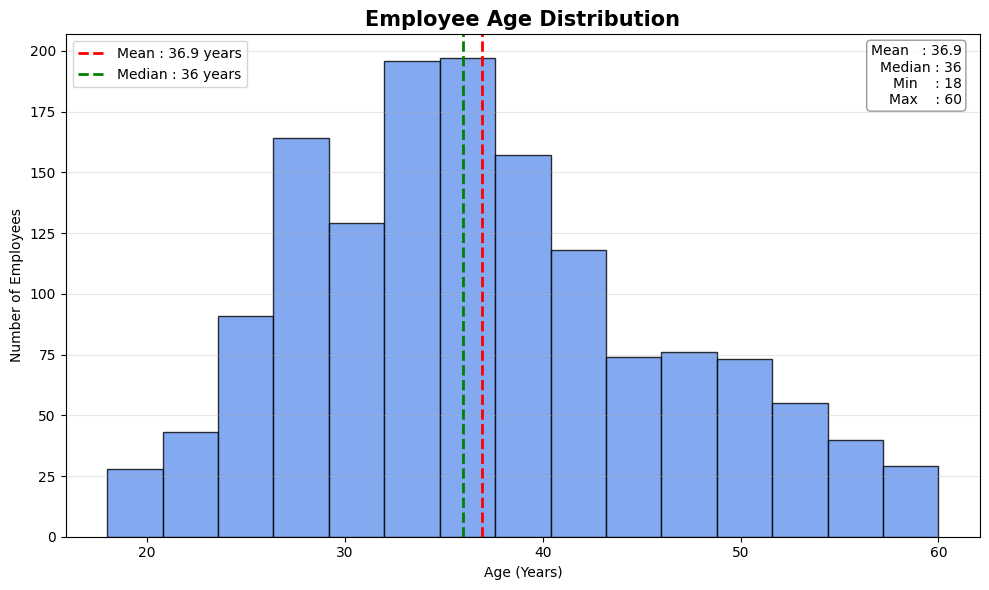

In [79]:
fig, ax = plt.subplots(figsize=(10,6))

# Histogram
ax.hist(
    df["Age"],
    bins=15,
    color="cornflowerblue",
    edgecolor="black",
    alpha=0.8
)

# Mean & Median
mean_age = df["Age"].mean()
median_age = df["Age"].median()

ax.axvline(
    mean_age,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean : {mean_age:.1f} years"
)

ax.axvline(
    median_age,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median : {median_age:.0f} years"
)

# Statistik
stats_text = (
    f"Mean   : {mean_age:.1f}\n"
    f"Median : {median_age:.0f}\n"
    f"Min    : {df['Age'].min()}\n"
    f"Max    : {df['Age'].max()}"
)

ax.text(
    0.98,
    0.98,
    stats_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        alpha=0.8,
        boxstyle="round"
    )
)

# Judul dan label
ax.set_title(
    "Employee Age Distribution",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Age (Years)")
ax.set_ylabel("Number of Employees")

# Grid
ax.grid(axis="y", alpha=0.3)

# Legend
ax.legend()

plt.tight_layout()
plt.show()

**CLEAN CODE FOR ATTRITION RATE**

In [75]:
def plot_attrition_rate(data, title, color, figsize=(8,5)):
    fig, ax = plt.subplots(figsize=figsize)

    data.plot(
        kind="bar",
        color=color,
        edgecolor="black",
        ax=ax
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_ylabel("Attrition Rate (%)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3,
            fontsize=10,
            weight="bold"
        )

    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, data.max() + 8)

    plt.tight_layout()
    plt.show()

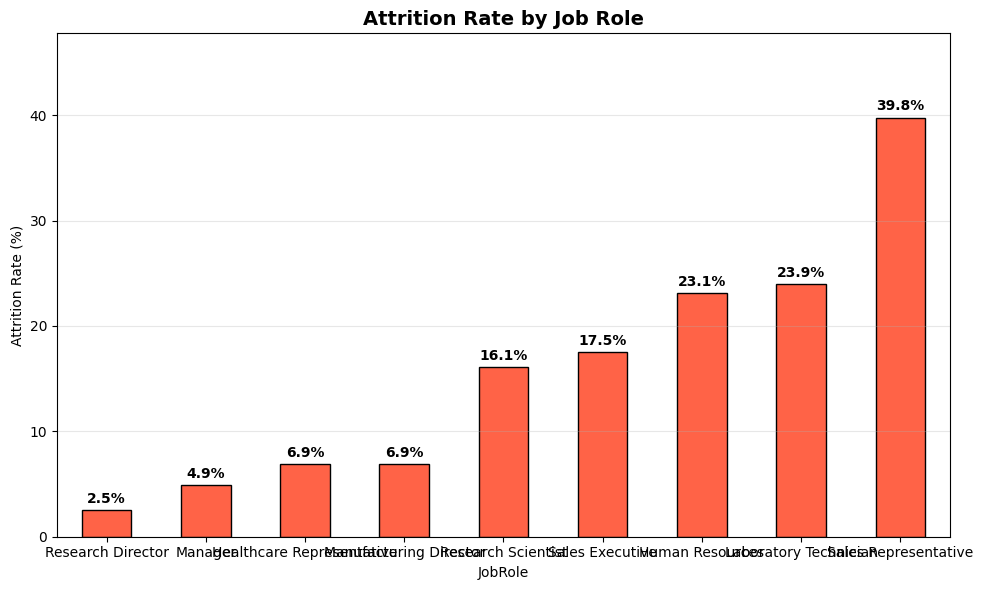

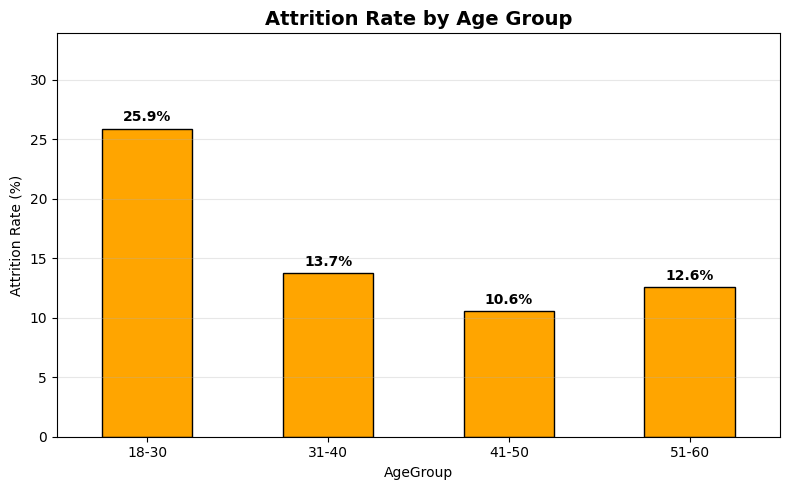

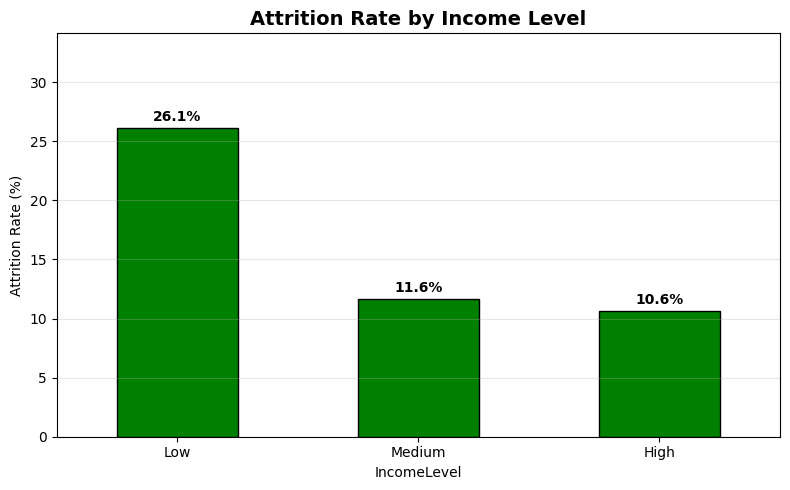

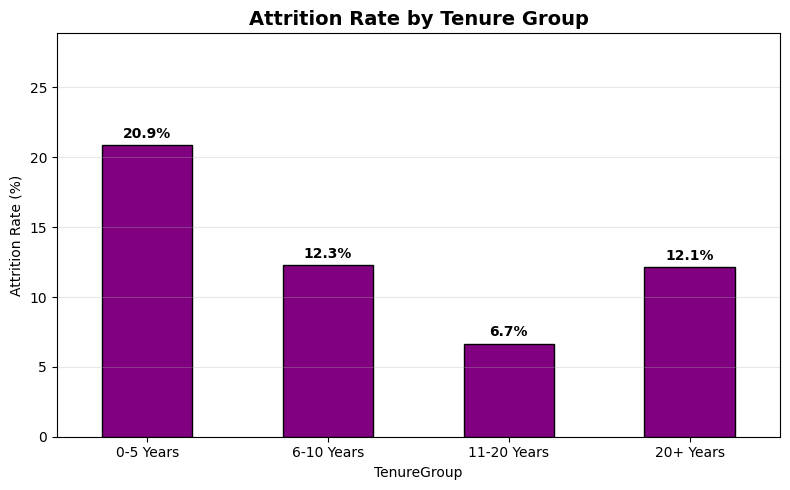

In [76]:
plot_attrition_rate(jobrole_rate["Yes"].sort_values(), "Attrition Rate by Job Role", "tomato", figsize=(10,6))

plot_attrition_rate(age_rate["Yes"], "Attrition Rate by Age Group", "orange")

plot_attrition_rate(income_rate["Yes"], "Attrition Rate by Income Level", "green")

plot_attrition_rate(tenure_rate["Yes"], "Attrition Rate by Tenure Group", "purple")

-------------------------------------

# **Correlation Analysis**

Correlation analysis helps identify relationships between numerical variables in the dataset.

This analysis supports HR decision-making by highlighting which employee characteristics tend to change together and may influence employee attrition.

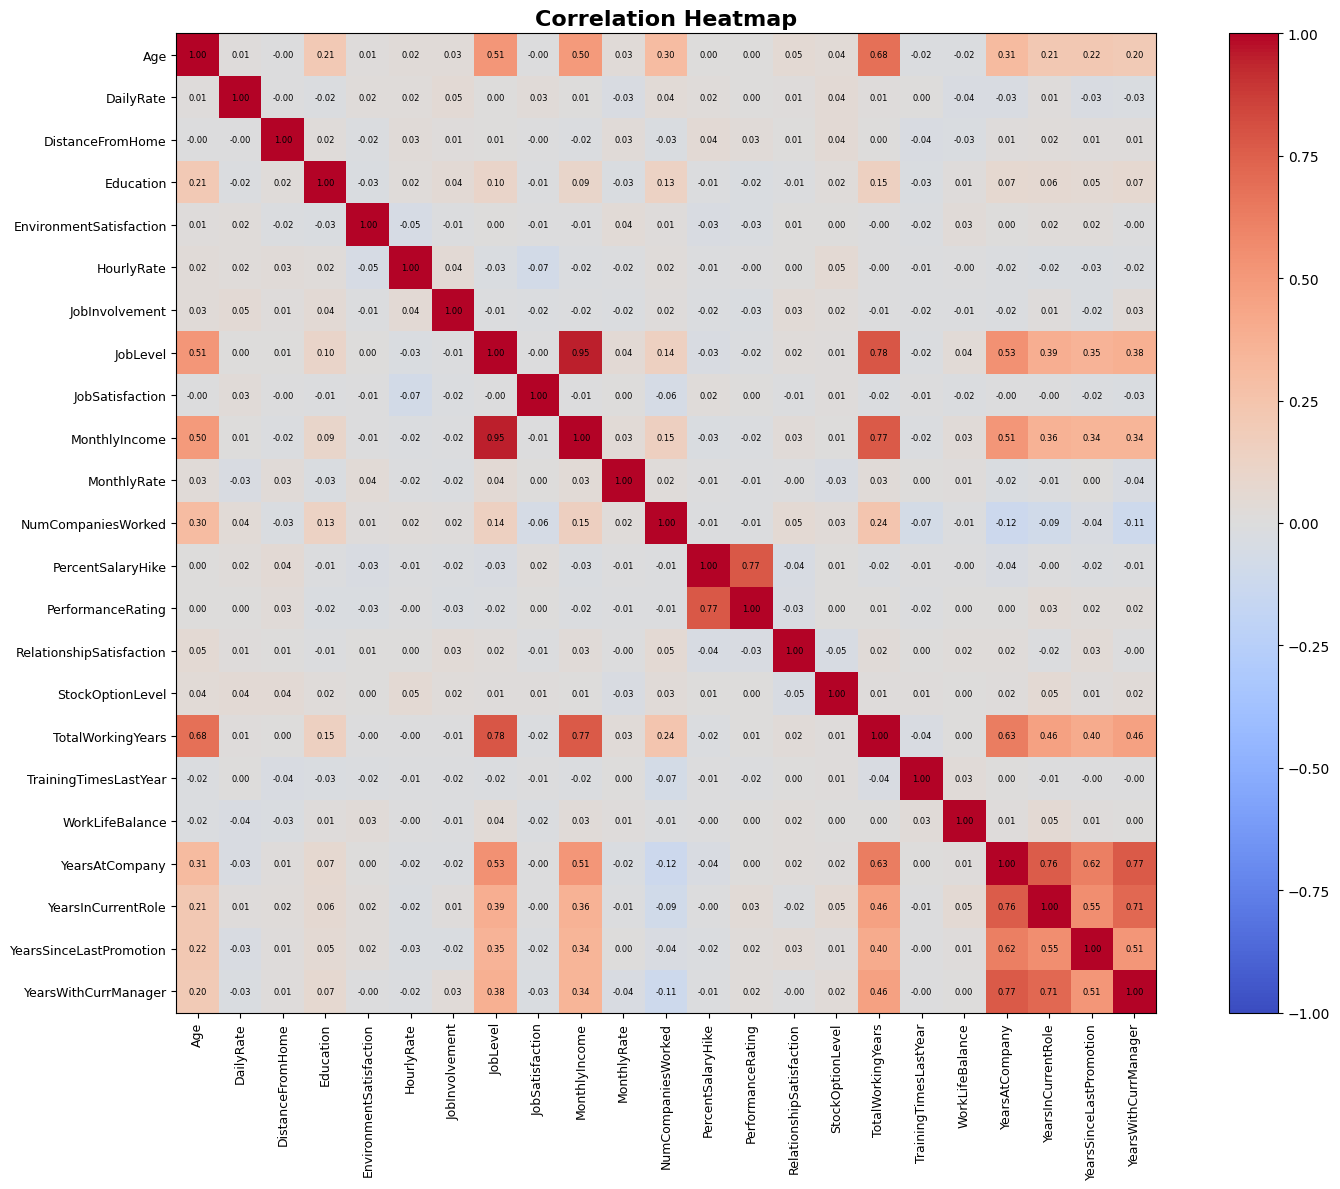

In [81]:
fig, ax = plt.subplots(figsize=(16,12))

im = ax.imshow(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=90, fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=6
        )

plt.colorbar(im)

plt.title(
    "Correlation Heatmap",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()

plt.show()

In [82]:
corr_target = corr["MonthlyIncome"].sort_values(ascending=False)

corr_target

,MonthlyIncome
MonthlyIncome,1.000000
JobLevel,0.950300
TotalWorkingYears,0.772893
YearsAtCompany,0.514285
Age,0.497855
YearsInCurrentRole,0.363818
YearsSinceLastPromotion,0.344978
YearsWithCurrManager,0.344079
NumCompaniesWorked,0.149515
Education,0.094961


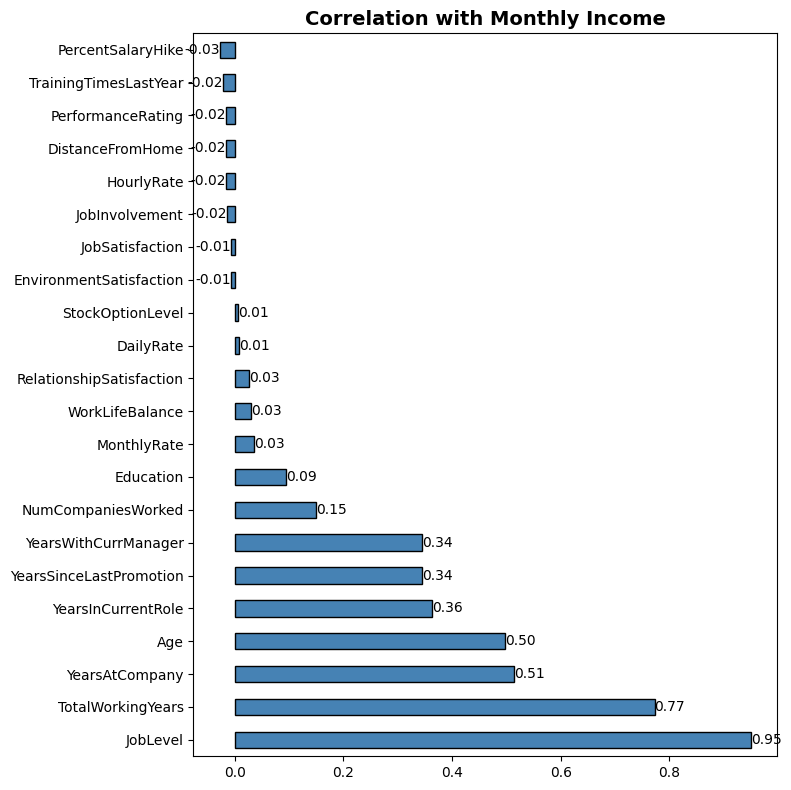

In [83]:
fig, ax = plt.subplots(figsize=(8,8))

corr_target.drop("MonthlyIncome").plot(
    kind="barh",
    color="steelblue",
    edgecolor="black",
    ax=ax
)

ax.set_title(
    "Correlation with Monthly Income",
    fontsize=14,
    weight="bold"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f"
    )

plt.tight_layout()

plt.show()

In [84]:
df["AttritionNumeric"] = df["Attrition"].map({
    "No":0,
    "Yes":1
})

In [85]:
corr = df.select_dtypes(include=["int64","float64"]).corr()

corr["AttritionNumeric"].sort_values()

,AttritionNumeric
TotalWorkingYears,-0.171063
JobLevel,-0.169105
YearsInCurrentRole,-0.160545
MonthlyIncome,-0.159840
Age,-0.159205
YearsWithCurrManager,-0.156199
StockOptionLevel,-0.137145
YearsAtCompany,-0.134392
JobInvolvement,-0.130016
JobSatisfaction,-0.103481


**COUNT OF KPI**

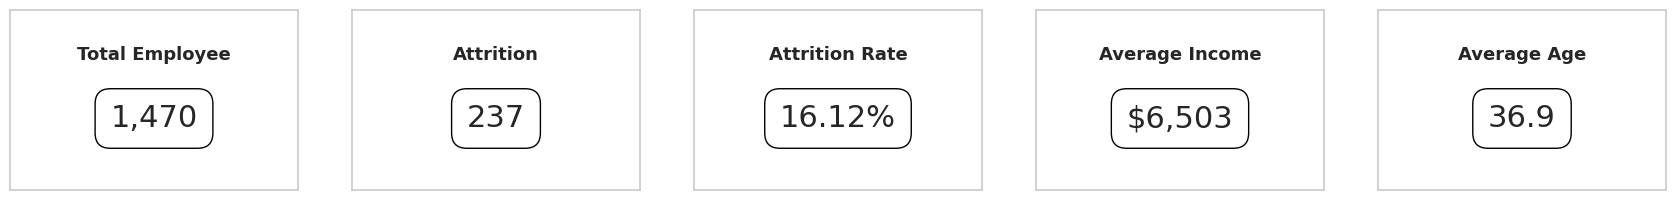

In [103]:
import matplotlib.pyplot as plt

# ==========================
# KPI
# ==========================
total_employee = len(df)
attrition = (df["Attrition"]=="Yes").sum()
attrition_rate = attrition / total_employee * 100
avg_income = df["MonthlyIncome"].mean()
avg_age = df["Age"].mean()

fig = plt.figure(figsize=(18,3))
fig.patch.set_facecolor("white")

kpis = [
    ("Total Employee", f"{total_employee:,}"),
    ("Attrition", f"{attrition:,}"),
    ("Attrition Rate", f"{attrition_rate:.2f}%"),
    ("Average Income", f"${avg_income:,.0f}"),
    ("Average Age", f"{avg_age:.1f}")
]

for i, (title, value) in enumerate(kpis):

    ax = fig.add_axes([0.03 + i*0.19, 0.2, 0.16, 0.6])

    ax.set_xticks([])
    ax.set_yticks([])

    ax.text(
        0.5,
        0.72,
        title,
        fontsize=13,
        weight="bold",
        ha="center"
    )

    ax.text(
        0.5,
        0.35,
        value,
        fontsize=22,
        ha="center",
        bbox=dict(
            boxstyle="round,pad=0.5",
            fc="white",
            ec="black"
        )
    )

plt.show()

E**xecutive Dashboard**

The executive dashboard summarizes the key HR metrics and visualizations into a single page, providing managers with an overview of employee attrition.

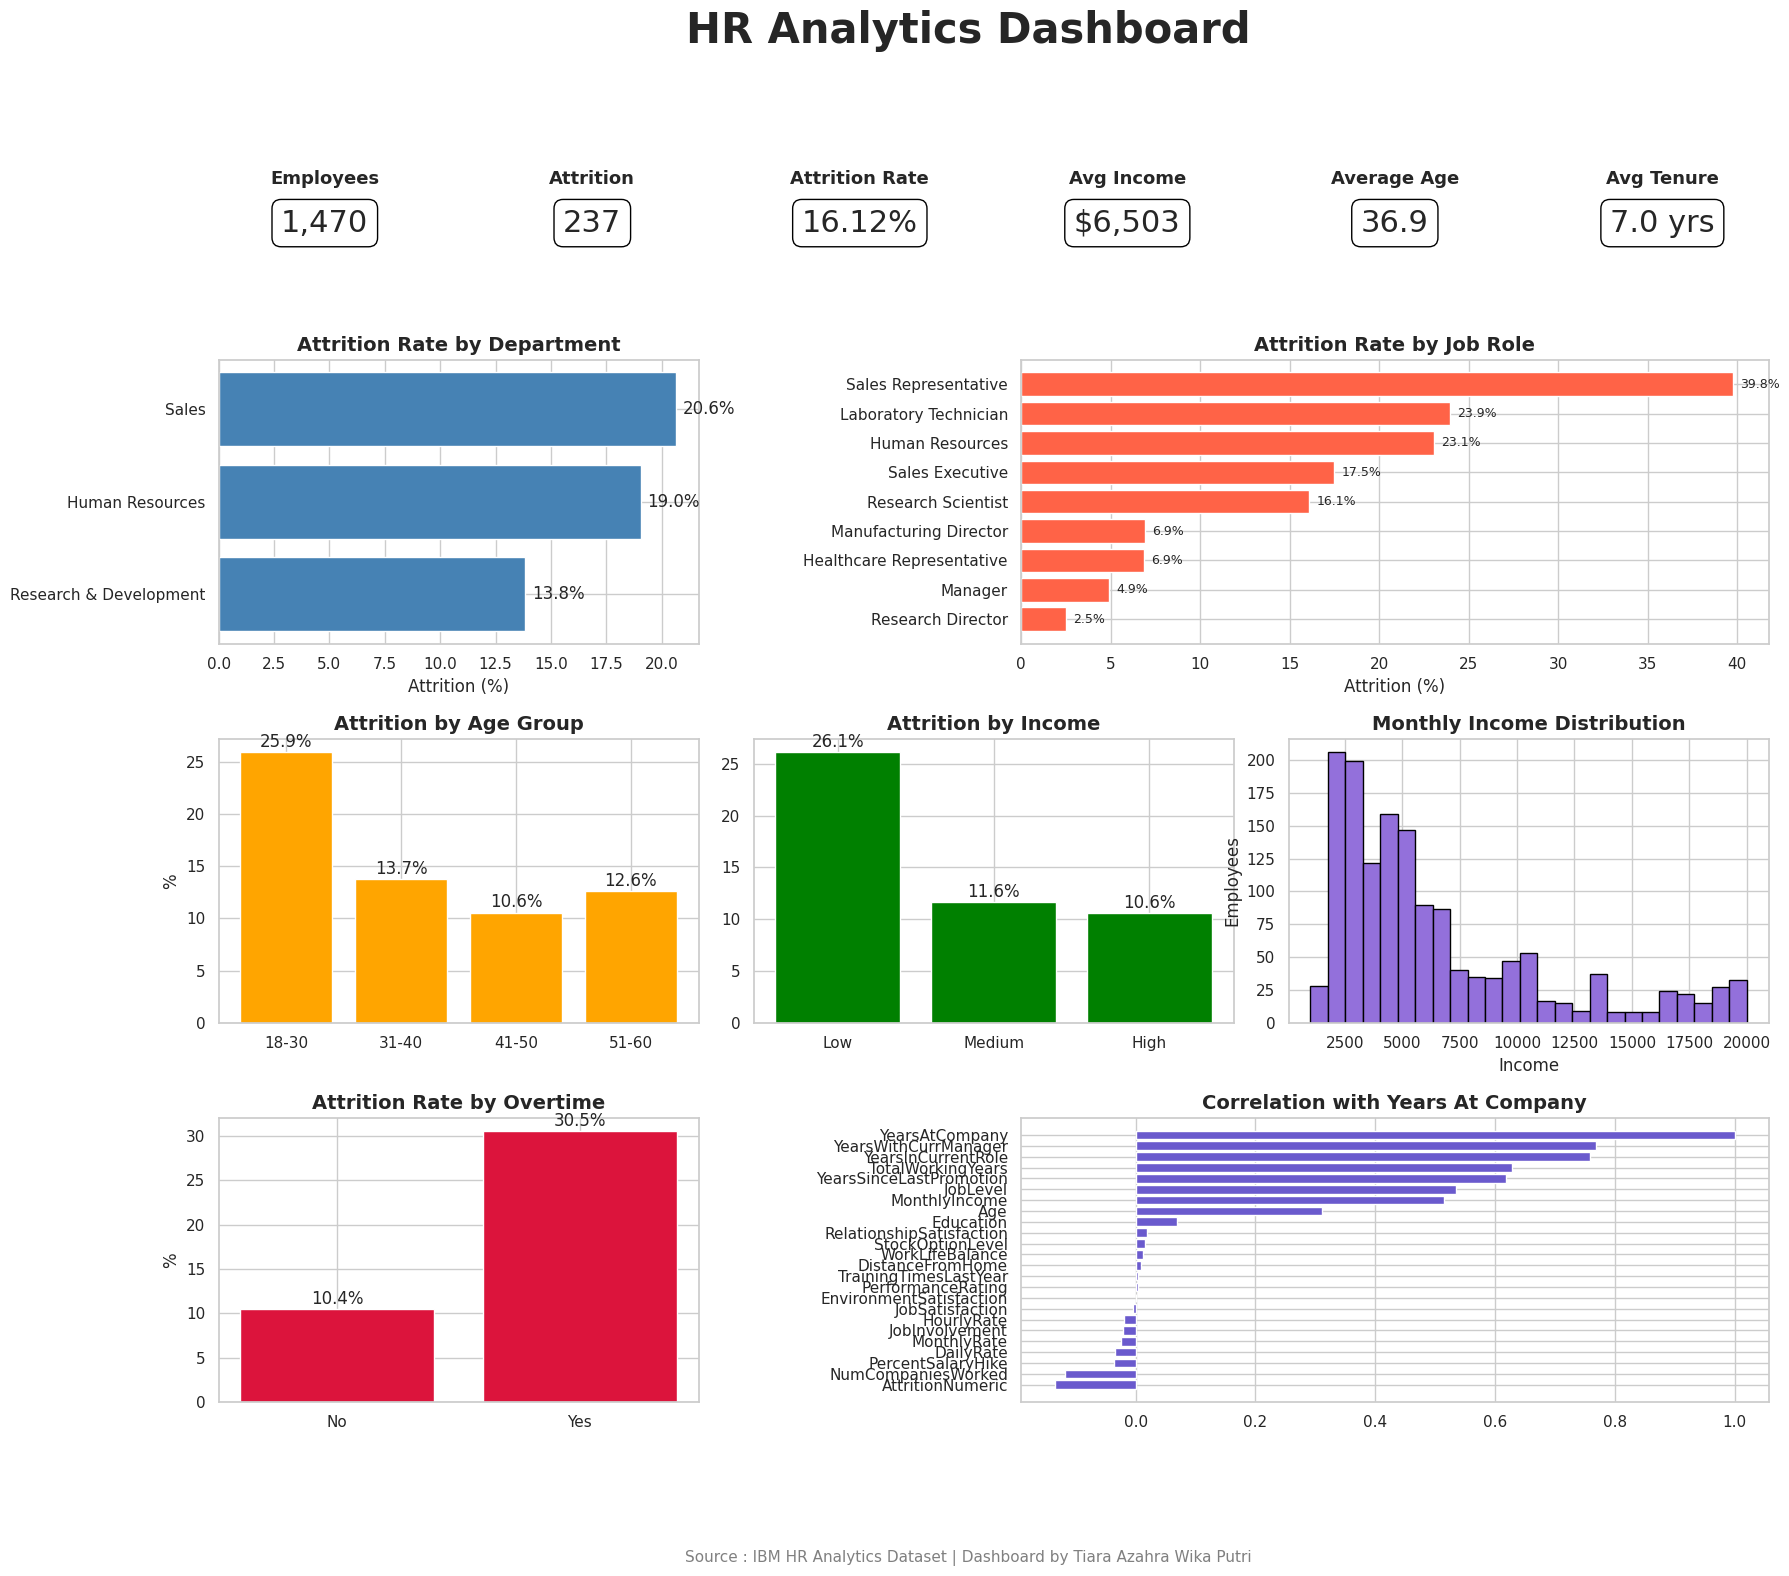

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ==============================
# KPI
# ==============================

total_employee = len(df)
attrition_count = (df["Attrition"]=="Yes").sum()
attrition_rate = attrition_count/total_employee*100
avg_income = df["MonthlyIncome"].mean()
avg_age = df["Age"].mean()
avg_year = df["YearsAtCompany"].mean()

# ==============================
# Figure
# ==============================

fig = plt.figure(figsize=(20,16), facecolor="white")

gs = GridSpec(
    20,
    12,
    figure=fig,
    hspace=1.0,
    wspace=0.7
)

fig.suptitle(
    "HR Analytics Dashboard",
    fontsize=30,
    fontweight="bold",
    y=0.98
)

# ==============================
# KPI CARDS
# ==============================

kpis = [
    ("Employees", f"{total_employee:,}"),
    ("Attrition", f"{attrition_count:,}"),
    ("Attrition Rate", f"{attrition_rate:.2f}%"),
    ("Avg Income", f"${avg_income:,.0f}"),
    ("Average Age", f"{avg_age:.1f}"),
    ("Avg Tenure", f"{avg_year:.1f} yrs")
]

positions = [0,2,4,6,8,10]

for i,(title,value) in enumerate(kpis):

    ax = fig.add_subplot(gs[0:2, positions[i]:positions[i]+2])

    ax.axis("off")

    ax.text(
        0.5,
        0.85,
        title,
        ha="center",
        fontsize=13,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.35,
        value,
        ha="center",
        fontsize=22,
        bbox=dict(
            boxstyle="round",
            fc="white",
            ec="black"
        )
    )

# ======================================================
# 1 Department
# ======================================================

ax1 = fig.add_subplot(gs[3:8,0:4])

dept = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
)*100

dept = dept["Yes"].sort_values()

bars=ax1.barh(
    dept.index,
    dept.values,
    color="steelblue"
)

ax1.set_title(
    "Attrition Rate by Department",
    fontsize=14,
    fontweight="bold"
)

ax1.set_xlabel("Attrition (%)")

for bar in bars:
    ax1.text(
        bar.get_width()+0.3,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.1f}%",
        va="center"
    )

# ======================================================
# 2 Job Role
# ======================================================

ax2 = fig.add_subplot(gs[3:8,6:12])

job = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
)*100

job = job["Yes"].sort_values()

bars=ax2.barh(
    job.index,
    job.values,
    color="tomato"
)

ax2.set_title(
    "Attrition Rate by Job Role",
    fontsize=14,
    fontweight="bold"
)

ax2.set_xlabel("Attrition (%)")

for bar in bars:
    ax2.text(
        bar.get_width()+0.4,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.1f}%",
        va="center",
        fontsize=9
    )

# ======================================================
# 3 Age Group
# ======================================================

ax3 = fig.add_subplot(gs[9:14,0:4])

age = pd.crosstab(
    df["AgeGroup"],
    df["Attrition"],
    normalize="index"
)*100

bars=ax3.bar(
    age.index.astype(str),
    age["Yes"],
    color="orange"
)

ax3.set_title(
    "Attrition by Age Group",
    fontsize=14,
    fontweight="bold"
)

ax3.set_ylabel("%")

for bar in bars:
    ax3.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.5,
        f"{bar.get_height():.1f}%",
        ha="center"
    )

# ======================================================
# 4 Income
# ======================================================

ax4 = fig.add_subplot(gs[9:14,4:8])

income = pd.crosstab(
    df["IncomeLevel"],
    df["Attrition"],
    normalize="index"
)*100

bars=ax4.bar(
    income.index.astype(str),
    income["Yes"],
    color="green"
)

ax4.set_title(
    "Attrition by Income",
    fontsize=14,
    fontweight="bold"
)

for bar in bars:
    ax4.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.5,
        f"{bar.get_height():.1f}%",
        ha="center"
    )

# ======================================================
# 5 Monthly Income
# ======================================================

ax5 = fig.add_subplot(gs[9:14,8:12])

ax5.hist(
    df["MonthlyIncome"],
    bins=25,
    edgecolor="black",
    color="mediumpurple"
)

ax5.set_title(
    "Monthly Income Distribution",
    fontsize=14,
    fontweight="bold"
)

ax5.set_xlabel("Income")

ax5.set_ylabel("Employees")

# ======================================================
# 6 Overtime
# ======================================================

ax6 = fig.add_subplot(gs[15:20,0:4])

over = pd.crosstab(
    df["OverTime"],
    df["Attrition"],
    normalize="index"
)*100

bars=ax6.bar(
    over.index.astype(str),
    over["Yes"],
    color="crimson"
)

ax6.set_title(
    "Attrition Rate by Overtime",
    fontsize=14,
    fontweight="bold"
)

ax6.set_ylabel("%")

for bar in bars:
    ax6.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.6,
        f"{bar.get_height():.1f}%",
        ha="center"
    )

# ======================================================
# 7 Correlation
# ======================================================

ax7 = fig.add_subplot(gs[15:20,6:12])

corr = df.select_dtypes(include="number").corr()["YearsAtCompany"]\
         .sort_values()

ax7.barh(
    corr.index,
    corr.values,
    color="slateblue"
)

ax7.set_title(
    "Correlation with Years At Company",
    fontsize=14,
    fontweight="bold"
)

# ======================================================

plt.figtext(
    0.5,
    0.01,
    "Source : IBM HR Analytics Dataset | Dashboard by Tiara Azahra Wika Putri",
    ha="center",
    fontsize=11,
    color="gray"
)

plt.savefig(
    "HR_Analytics_Dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# **8. Business Insights**

The analysis identified several key factors associated with employee attrition. These findings can help HR managers prioritize retention strategies and improve workforce stability.

---

## 1. Overtime Significantly Increases Employee Attrition

Employees who work overtime experience a substantially higher attrition rate than those who do not.

**Business Recommendation**

- Monitor employee workload regularly.
- Reduce excessive overtime.
- Promote a healthier work-life balance.

---

## 2. Employees in Lower Income Groups Are More Likely to Leave

The analysis indicates that lower-income employees show higher attrition rates.

**Business Recommendation**

- Review salary competitiveness.
- Introduce performance-based incentives.
- Provide clearer career progression opportunities.

---

## 3. Early-Career Employees Require Greater Retention Efforts

Most resignations occur during the first five years of employment.

**Business Recommendation**

- Strengthen onboarding programs.
- Conduct regular employee engagement surveys.
- Implement mentoring and coaching initiatives.

---

## 4. Certain Job Roles Have Higher Attrition Rates

Sales Representatives and Laboratory Technicians exhibit the highest turnover.

**Business Recommendation**

- Evaluate workload and performance targets.
- Improve role-specific career development plans.
- Review compensation and recognition programs.

---

## 5. Age Is More Influential Than Gender

Younger employees tend to resign more frequently, while gender shows relatively little difference in attrition.

**Business Recommendation**

- Design retention programs tailored for younger employees.
- Focus on career development and professional growth opportunities.

# 9. Executive Summary

This project analyzed the IBM HR Analytics Employee Attrition dataset to identify patterns related to employee turnover.

The analysis shows that overtime, income level, years at company, and job role are the primary factors associated with attrition, whereas gender has relatively little impact.

These findings suggest that HR departments should prioritize workload management, competitive compensation, onboarding programs, and targeted retention strategies for high-risk employee groups.

The project demonstrates an end-to-end HR Analytics workflow, including data cleaning, feature engineering, exploratory data analysis, dashboard development, and business insight generation using Python.

# 🏁 Conclusion

This project demonstrates practical data analytics skills by transforming raw HR data into actionable business insights.

Key competencies demonstrated include:

- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Data Visualization
- Dashboard Development
- Business Insight Generation

The results provide evidence-based recommendations that can support Human Resource decision-making and improve employee retention strategies.